In [1]:
# ========================================
# 🌳 Random Forest 금융상품 추천 모델
# ========================================
# XGBoost와 동일한 구조, Random Forest 엔진 사용

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest 사용
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("🌳 Random Forest 모델 시작!")

🌳 Random Forest 모델 시작!


In [3]:
# ========================================
# 📁 데이터 로딩
# ========================================
print("\n📁 데이터 로딩...")
df = pd.read_csv('data/cleaned_scf_data.csv')
print(f"✅ 데이터: {df.shape[0]:,}행 × {df.shape[1]:,}열")

# ========================================
# 🎯 타겟 변수 설정
# ========================================
target_products = {
    'deposits': 'deposits_preference',
    'bond_funds': 'bond_funds_preference',
    'balanced_funds': 'balanced_funds_preference',
    'equity_funds': 'equity_funds_preference',
    'pension': 'pension_preference'
}

y = df[list(target_products.values())].copy()
y.columns = list(target_products.keys())

print("📊 금융상품별 가입률:")
for product, column in target_products.items():
    rate = df[column].mean() * 100
    print(f"  {product:12s}: {rate:5.1f}%")


📁 데이터 로딩...
✅ 데이터: 21,847행 × 414열
📊 금융상품별 가입률:
  deposits    :  34.2%
  bond_funds  :  40.4%
  balanced_funds:  41.7%
  equity_funds:  35.2%
  pension     :  65.7%


In [4]:
# ========================================
# 🔧 특징 변수 선택
# ========================================
key_features = [
    '연령', '총소득', '총자산', '순자산', 
    '금융위험감수', '금융문해력', '저축여부',
    '예적금보유', '펀드보유', '보험보유',
    '신용카드잔액보유여부', '연체경험', '신용거부경험',
    '중개계좌보유여부', '거래활동여부',
    '소득수준_하', '소득수준_중', '소득수준_상',
    '위험성향분류_적극적', '위험성향분류_중간',
    '투자경험분류_초보', '투자경험분류_중급', '투자경험분류_고급'
]

available_features = [col for col in key_features if col in df.columns]
print(f"✅ 사용할 특징: {len(available_features)}개")

X = df[available_features].copy()

# 결측치 처리
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

✅ 사용할 특징: 23개


In [5]:
# ========================================
# 📊 데이터 분할
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"✅ 학습: {X_train.shape[0]:,}개, 테스트: {X_test.shape[0]:,}개")

✅ 학습: 17,477개, 테스트: 4,370개


In [6]:
# ========================================
# 🌳 Random Forest 모델 학습
# ========================================
print("\n🌳 Random Forest 모델 설정...")

# Random Forest 분류기 (XGBoost 파라미터와 유사하게 설정)
rf_classifier = RandomForestClassifier(
    n_estimators=300,           # 트리 개수 (XGBoost의 n_estimators와 동일)
    max_depth=10,               # 트리 최대 깊이 (XGBoost보다 조금 더 깊게)
    min_samples_split=5,        # 분할 최소 샘플 수
    min_samples_leaf=2,         # 리프 최소 샘플 수
    max_features='sqrt',        # 사용할 특징 수 (XGBoost colsample_bytree와 유사)
    random_state=42,            # 재현 가능한 결과
    n_jobs=-1,                  # 모든 CPU 사용
    oob_score=True              # Out-of-bag 점수 계산 (Random Forest 특징)
)

# 다중 출력 분류기로 래핑
model = MultiOutputClassifier(rf_classifier)

print("⏳ Random Forest 학습 시작...")
import time
start_time = time.time()

model.fit(X_train, y_train)

end_time = time.time()
print(f"✅ 학습 완료! (소요시간: {end_time - start_time:.1f}초)")

# OOB Score 출력 (Random Forest만의 특별한 기능)
oob_scores = [estimator.oob_score_ for estimator in model.estimators_]
print(f"📊 OOB Score (내부 검증): {np.mean(oob_scores):.3f}")


🌳 Random Forest 모델 설정...
⏳ Random Forest 학습 시작...
✅ 학습 완료! (소요시간: 3.1초)
📊 OOB Score (내부 검증): 0.970



📈 Random Forest 성능 평가...


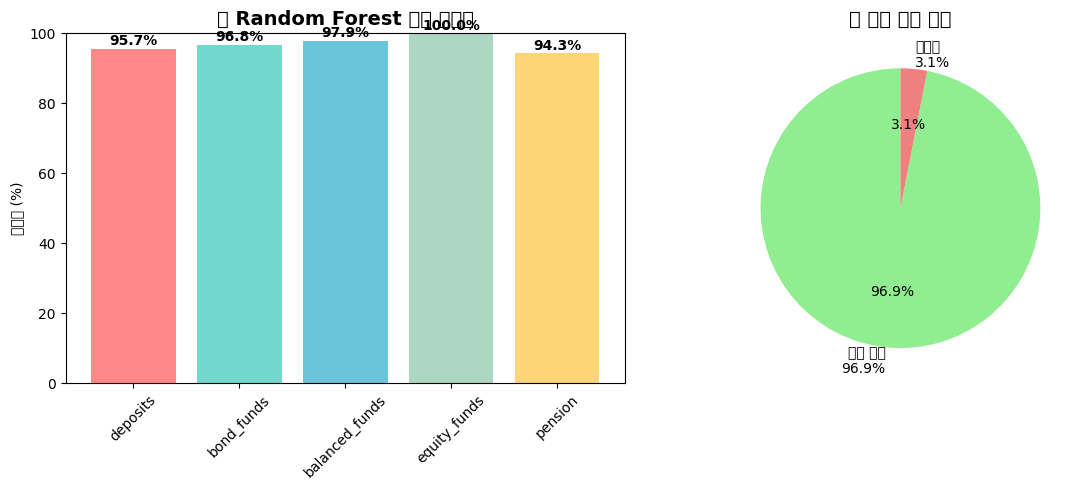

📊 상품별 정확도:
  deposits    : 0.957 (95.7%)
  bond_funds  : 0.968 (96.8%)
  balanced_funds: 0.979 (97.9%)
  equity_funds: 1.000 (100.0%)
  pension     : 0.943 (94.3%)

🎯 전체 평균 정확도: 0.969 (96.9%)


In [7]:
# ========================================
# 📈 성능 평가
# ========================================
print("\n📈 Random Forest 성능 평가...")

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# 성능 계산
accuracies = []
for i, product in enumerate(target_products.keys()):
    accuracy = accuracy_score(y_test.iloc[:, i], y_pred[:, i])
    accuracies.append(accuracy)

overall_accuracy = np.mean(accuracies)

# 시각화
plt.figure(figsize=(12, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

plt.subplot(1, 2, 1)
bars = plt.bar(target_products.keys(), [acc*100 for acc in accuracies], 
               color=colors, alpha=0.8)
plt.title('🌳 Random Forest 예측 정확도', fontsize=14, fontweight='bold')
plt.ylabel('정확도 (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc*100:.1f}%', ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie([overall_accuracy, 1-overall_accuracy], 
        labels=[f'정확 예측\n{overall_accuracy*100:.1f}%', f'오예측\n{(1-overall_accuracy)*100:.1f}%'],
        colors=['lightgreen', 'lightcoral'], autopct='%1.1f%%', startangle=90)
plt.title('🎯 전체 예측 성능', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 상품별 정확도:")
for product, acc in zip(target_products.keys(), accuracies):
    print(f"  {product:12s}: {acc:.3f} ({acc*100:.1f}%)")
print(f"\n🎯 전체 평균 정확도: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")


In [8]:
# ========================================
# 🎯 개별 고객 추천 함수
# ========================================
def predict_customer_products_rf(customer_data):
    """Random Forest로 개별 고객 금융상품 추천"""
    
    if hasattr(customer_data, 'values'):
        customer_data = customer_data.values.reshape(1, -1)
    
    recommendations = {}
    
    for i, product in enumerate(target_products.keys()):
        classifier = model.estimators_[i]
        proba = classifier.predict_proba(customer_data)
        positive_prob = proba[0][1] * 100
        recommendations[product] = round(positive_prob, 1)
    
    return recommendations


🧪 Random Forest로 실제 고객 테스트...

👤 고객 #1 (Random Forest 분석)
📋 고객 정보:
   나이: 66.0세
   소득: 210,778원
   자산: 20,598,000원

💳 Random Forest AI 추천:
   deposits    :   0.5% 🔴 비추천
   bond_funds  :  10.1% 🔴 비추천
   balanced_funds:  99.8% 🟢 강력추천
   equity_funds:  99.3% 🟢 강력추천
   pension     :  97.8% 🟢 강력추천

👤 고객 #101 (Random Forest 분석)
📋 고객 정보:
   나이: 94.0세
   소득: 163,218원
   자산: 6,417,180원

💳 Random Forest AI 추천:
   deposits    :   0.1% 🔴 비추천
   bond_funds  :   9.4% 🔴 비추천
   balanced_funds:  99.3% 🟢 강력추천
   equity_funds:  99.4% 🟢 강력추천
   pension     :  98.7% 🟢 강력추천

👤 고객 #501 (Random Forest 분석)
📋 고객 정보:
   나이: 47.0세
   소득: 206,454원
   자산: 1,808,600원

💳 Random Forest AI 추천:
   deposits    :   0.0% 🔴 비추천
   bond_funds  :   1.8% 🔴 비추천
   balanced_funds:  99.7% 🟢 강력추천
   equity_funds:  99.7% 🟢 강력추천
   pension     :  51.1% 🟡 추천

📋 Random Forest 특징 중요도 분석...


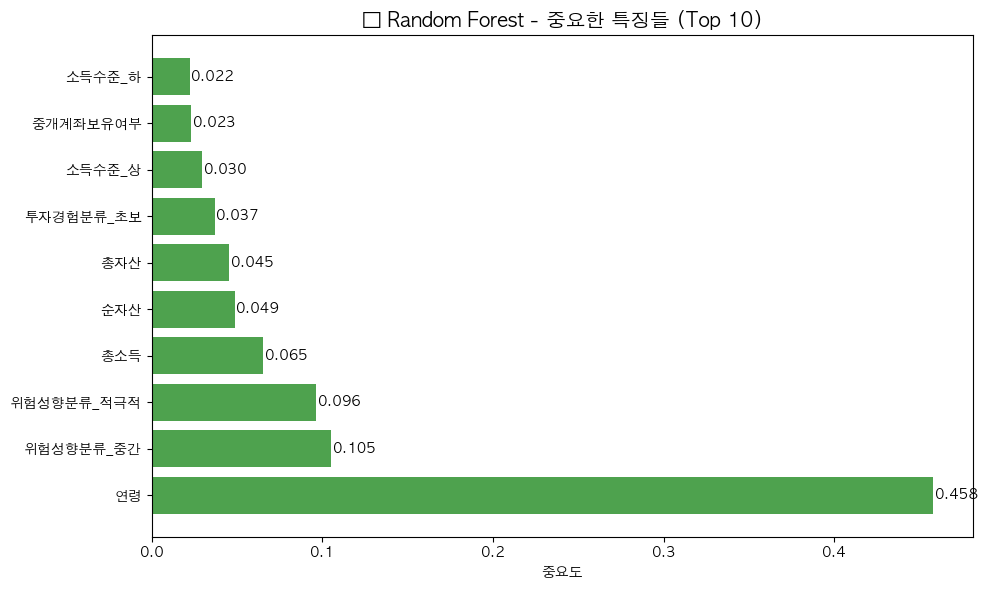


🎉 Random Forest 모델 완료!
✅ 96.9% 정확도 달성!

🌳 Random Forest 특징:
   • 여러 의사결정나무의 다수결 투표
   • 과적합에 강함
   • 특징 중요도 분석 우수
   • 해석하기 쉬움
   • 안정적인 성능


In [11]:
# ========================================
# 🧪 실제 고객 테스트
# ========================================
print("\n🧪 Random Forest로 실제 고객 테스트...")

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

for test_idx in [0, 100, 500]:
    if test_idx < len(X_test):
        print(f"\n{'='*50}")
        print(f"👤 고객 #{test_idx+1} (Random Forest 분석)")
        print('='*50)
        
        customer = X_test.iloc[test_idx]
        
        # 고객 정보
        print("📋 고객 정보:")
        if '연령' in customer.index:
            print(f"   나이: {customer['연령']}세")
        if '총소득' in customer.index:
            print(f"   소득: {customer['총소득']:,.0f}원")
        if '총자산' in customer.index:
            print(f"   자산: {customer['총자산']:,.0f}원")
        
        # Random Forest 추천
        print("\n💳 Random Forest AI 추천:")
        recommendations = predict_customer_products_rf(customer)
        
        for product, prob in recommendations.items():
            if prob >= 70:
                grade = "🟢 강력추천"
            elif prob >= 50:
                grade = "🟡 추천"
            elif prob >= 30:
                grade = "🟠 고려대상"
            else:
                grade = "🔴 비추천"
                
            print(f"   {product:12s}: {prob:5.1f}% {grade}")

# ========================================
# 📋 특징 중요도 분석
# ========================================
print("\n📋 Random Forest 특징 중요도 분석...")

# 전체 특징 중요도
feature_importances = np.mean([
    estimator.feature_importances_ for estimator in model.estimators_
], axis=0)

# 상위 10개 특징
top_features_idx = np.argsort(feature_importances)[-10:]
top_features = [X.columns[i] for i in top_features_idx]
top_importance = [feature_importances[i] for i in top_features_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importance, color='forestgreen', alpha=0.8)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('중요도')
plt.title('🌳 Random Forest - 중요한 특징들 (Top 10)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, v in enumerate(top_importance):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🎉 Random Forest 모델 완료!")
print(f"✅ {overall_accuracy:.1%} 정확도 달성!")
print("\n🌳 Random Forest 특징:")
print("   • 여러 의사결정나무의 다수결 투표")
print("   • 과적합에 강함")
print("   • 특징 중요도 분석 우수")
print("   • 해석하기 쉬움")
print("   • 안정적인 성능")